=== Q4  European binomial prices (N=2000) ===
       Option  Price ($)
European Call       4.61
 European Put       3.37

=== Q5  European Delta ===
       Option  Delta
European Call   0.57
 European Put  -0.43

=== Q6  Vega (20% -> 25% vol) ===
       Option  Price @20% ($)  Price @25% ($)  Change ($)
European Call            4.61            5.60        0.98
 European Put            3.37            4.36        0.98

=== Q7  American binomial prices ===
       Option  Price ($)
American Call       4.61
 American Put       3.48

=== Q8  American Delta ===
       Option  Delta
American Call   0.57
 American Put  -0.45

=== Q9  Trinomial across 5 strikes ===
 Strike  Moneyness K/S0  Call ($)  Put ($)  C-P ($)  S0-Ke^-rT ($)
     90            0.90     11.67     0.55    11.12          11.12
     95            0.95      7.71     1.53     6.18           6.18
    100            1.00      4.61     3.37     1.24           1.24
    105            1.05      2.48     6.17    -3.70          -3.70


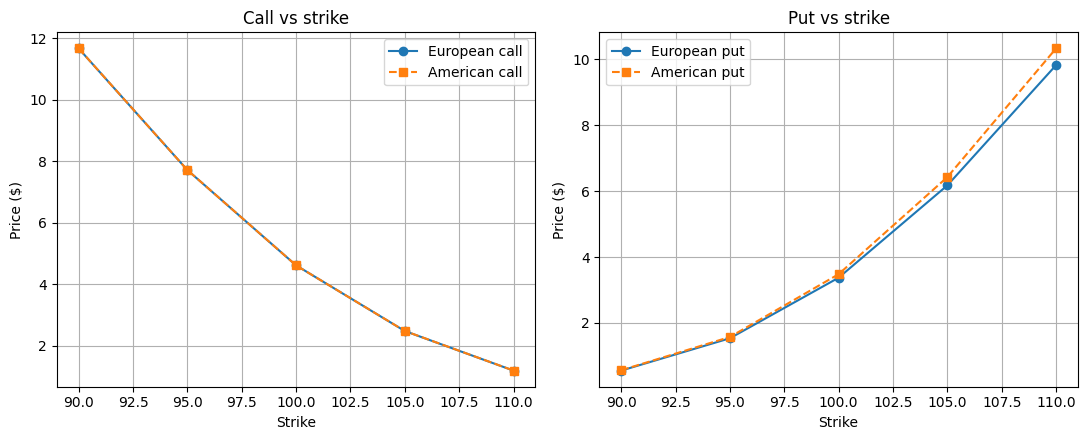


=== Q11-Q12  Heston ===
  rho  Call ($)  Put ($)  Call D  Call G  Put D  Put G  C-P ($)
-0.30      4.45     3.27    0.59    0.04  -0.41   0.04     1.19
-0.70      4.49     3.32    0.62    0.04  -0.38   0.04     1.17

=== Q13-Q14  Merton ===
 lambda  Call ($)  Put ($)  Call D  Call G  Put D  Put G  C-P ($)
   0.75      8.13     6.83    0.73    0.03  -0.27   0.03     1.30
   0.25      5.70     4.51    0.64    0.04  -0.36   0.04     1.20

=== Q15  Parity ===
             Model  C-P ($)  S0-Ke^-rT ($)  Parity?
   Heston rho=-0.3     1.19           1.24     True
   Heston rho=-0.7     1.17           1.24     True
Merton lambda=0.75     1.30           1.24     True
Merton lambda=0.25     1.20           1.24     True

=== Q16  Smile ===
 Strike ($)  Heston ($)  Merton ($)  BS ($)
     117.65        0.10        1.11    0.32
     111.11        0.63        2.69    1.00
     105.26        2.08        5.11    2.39
     100.00        4.57        8.18    4.61
      95.24        7.74       11.52    

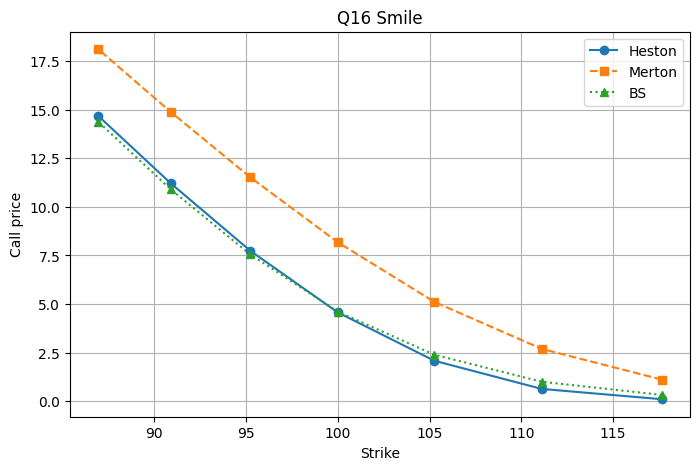


=== Q17  American Heston call ===
              Option  Price ($)  Delta  Gamma
American Heston Call       4.52   0.62  -0.04

=== Q18  Up-and-in call ===
    Instrument  Price ($)
Up-and-in call       0.77
    Plain call       0.77

=== Q19  Down-and-in put ===
     Instrument  Price ($)
Down-and-in put       4.38
      Plain put       4.38

=== Q20  3-step European put hedge (path D-U-U) ===
 Step  Stock ($)  Shares  Cash ($)
    0     100.00   -0.44     47.95
    1      94.39   -0.72     74.05
    2     100.00   -0.49     51.23
    3     105.94    0.00      0.00

=== Q21  American put 25-step hedge (first 6) ===
 Step  Stock ($)  Shares  Cash ($)
    0     100.00   -0.45     48.54
    1     102.02   -0.37     40.18
    2     100.00   -0.45     48.61
    3     102.02   -0.37     39.90
    4     104.08   -0.28     31.43
    5     102.02   -0.36     39.58
=== Q21  (last 6) ===
 Step  Stock ($)  Shares  Cash ($)
   20     104.08   -0.17     18.24
   21     102.02   -0.29     30.84
   2

In [6]:
# ============================================================
# HAcs 409 Derivative Pricing — Complete Notebook (single cell)
# Team Members A, B, C all active
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(0)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# -------- Base case --------
S0, K_ATM, r, T, sigma = 100.0, 100.0, 0.05, 0.25, 0.20

# ============================================================
# STEP 1 — Binomial / Trinomial trees
# ============================================================
def crr_tree(S0, K, r, T, sigma, N, option='call', american=False):
    dt = T/N; u = np.exp(sigma*np.sqrt(dt)); d = 1/u
    p = (np.exp(r*dt)-d)/(u-d); disc = np.exp(-r*dt)
    j = np.arange(N+1); ST = S0*u**(2*j-N)
    V = np.maximum(ST-K,0.0) if option=='call' else np.maximum(K-ST,0.0)
    for i in range(N-1,-1,-1):
        j_ = np.arange(i+1); S = S0*u**(2*j_-i)
        cont = disc*(p*V[1:]+(1-p)*V[:-1])
        if american:
            ex = np.maximum(S-K,0.0) if option=='call' else np.maximum(K-S,0.0)
            V = np.maximum(cont, ex)
        else:
            V = cont
    return V[0]

def crr_delta(S0,K,r,T,sig,N,option='call',american=False,h=0.5):
    Pu = crr_tree(S0+h,K,r,T,sig,N,option,american)
    Pd = crr_tree(S0-h,K,r,T,sig,N,option,american)
    return (Pu-Pd)/(2*h)

N = 2000
call_E = crr_tree(S0,K_ATM,r,T,sigma,N,'call',False)
put_E  = crr_tree(S0,K_ATM,r,T,sigma,N,'put', False)
call_A = crr_tree(S0,K_ATM,r,T,sigma,N,'call',True)
put_A  = crr_tree(S0,K_ATM,r,T,sigma,N,'put', True)
call_E_d = crr_delta(S0,K_ATM,r,T,sigma,N,'call',False)
put_E_d  = crr_delta(S0,K_ATM,r,T,sigma,N,'put', False)
call_A_d = crr_delta(S0,K_ATM,r,T,sigma,N,'call',True)
put_A_d  = crr_delta(S0,K_ATM,r,T,sigma,N,'put', True)

call_25 = crr_tree(S0,K_ATM,r,T,0.25,N,'call',False)
put_25  = crr_tree(S0,K_ATM,r,T,0.25,N,'put', False)

print("=== Q4  European binomial prices (N=2000) ===")
print(pd.DataFrame({"Option":["European Call","European Put"],
                    "Price ($)":[round(call_E,2),round(put_E,2)]}).to_string(index=False))

print("\n=== Q5  European Delta ===")
print(pd.DataFrame({"Option":["European Call","European Put"],
                    "Delta":[round(call_E_d,4),round(put_E_d,4)]}).to_string(index=False))

print("\n=== Q6  Vega (20% -> 25% vol) ===")
print(pd.DataFrame({"Option":["European Call","European Put"],
                    "Price @20% ($)":[round(call_E,2),round(put_E,2)],
                    "Price @25% ($)":[round(call_25,2),round(put_25,2)],
                    "Change ($)":[round(call_25-call_E,2),round(put_25-put_E,2)]}).to_string(index=False))

print("\n=== Q7  American binomial prices ===")
print(pd.DataFrame({"Option":["American Call","American Put"],
                    "Price ($)":[round(call_A,2),round(put_A,2)]}).to_string(index=False))

print("\n=== Q8  American Delta ===")
print(pd.DataFrame({"Option":["American Call","American Put"],
                    "Delta":[round(call_A_d,4),round(put_A_d,4)]}).to_string(index=False))

# Trinomial
def trinom(S0,K,r,T,sig,N,option='call'):
    dt=T/N; u=np.exp(sig*np.sqrt(2*dt)); d=1/u
    a=np.exp(r*dt/2); b=np.exp(sig*np.sqrt(dt/2)); c=np.exp(-sig*np.sqrt(dt/2))
    pu=((a-c)/(b-c))**2; pd=((b-a)/(b-c))**2; pm=1-pu-pd
    disc=np.exp(-r*dt)
    m=np.arange(-N,N+1); ST=S0*u**m
    V=np.maximum(ST-K,0.0) if option=='call' else np.maximum(K-ST,0.0)
    for _ in range(N-1,-1,-1):
        V=disc*(pu*V[2:]+pm*V[1:-1]+pd*V[:-2])
    return V[0]

strikes=[90,95,100,105,110]
rows=[]
for K_ in strikes:
    c=trinom(S0,K_,r,T,sigma,500,'call'); p=trinom(S0,K_,r,T,sigma,500,'put')
    rows.append({"Strike":K_,"Moneyness K/S0":round(K_/S0,2),
                 "Call ($)":round(c,2),"Put ($)":round(p,2),
                 "C-P ($)":round(c-p,2),
                 "S0-Ke^-rT ($)":round(S0-K_*np.exp(-r*T),2)})
q9=pd.DataFrame(rows)
print("\n=== Q9  Trinomial across 5 strikes ===")
print(q9.to_string(index=False))

# Q10
print("\n=== Q10a  Parity at ATM ===")
print(pd.DataFrame({"Metric":["C (E)","P (E)","C-P","S0-Ke^-rT","Diff"],
                    "Value ($)":[round(call_E,2),round(put_E,2),
                                 round(call_E-put_E,2),
                                 round(S0-K_ATM*np.exp(-r*T),2),
                                 round((call_E-put_E)-(S0-K_ATM*np.exp(-r*T)),4)]
                   }).to_string(index=False))

print("\n=== Q10b  European vs American ===")
print(pd.DataFrame({"Option":["Call","Put"],
                    "European ($)":[round(call_E,2),round(put_E,2)],
                    "American ($)":[round(call_A,2),round(put_A,2)],
                    "Diff ($)":[round(call_A-call_E,2),round(put_A-put_E,2)]}).to_string(index=False))

# Q10c graphs
ec=[trinom(S0,K_,r,T,sigma,500,'call') for K_ in strikes]
ac=[crr_tree(S0,K_,r,T,sigma,500,'call',True) for K_ in strikes]
ep=[trinom(S0,K_,r,T,sigma,500,'put')  for K_ in strikes]
ap=[crr_tree(S0,K_,r,T,sigma,500,'put', True) for K_ in strikes]
fig,ax=plt.subplots(1,2,figsize=(11,4.5))
ax[0].plot(strikes,ec,'o-',label='European call'); ax[0].plot(strikes,ac,'s--',label='American call')
ax[0].set_xlabel('Strike'); ax[0].set_ylabel('Price ($)'); ax[0].set_title('Call vs strike'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(strikes,ep,'o-',label='European put'); ax[1].plot(strikes,ap,'s--',label='American put')
ax[1].set_xlabel('Strike'); ax[1].set_ylabel('Price ($)'); ax[1].set_title('Put vs strike'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

# ============================================================
# STEP 2 — Heston & Merton Monte Carlo
# ============================================================
def heston_mc(S0,K,r,T,v0,kappa,theta,xi,rho,n_paths=20000,n_steps=100,
              option='call',payoff_func=None,seed=123):
    dt=T/n_steps; rng=np.random.default_rng(seed)
    Zv=rng.standard_normal((n_paths,n_steps))
    Zp=rng.standard_normal((n_paths,n_steps))
    S=np.zeros((n_paths,n_steps+1)); S[:,0]=S0
    v=np.zeros((n_paths,n_steps+1)); v[:,0]=v0
    for t in range(n_steps):
        vp=np.maximum(v[:,t],0)
        Zs=rho*Zv[:,t]+np.sqrt(1-rho**2)*Zp[:,t]
        v[:,t+1]=np.maximum(v[:,t]+kappa*(theta-vp)*dt+xi*np.sqrt(vp*dt)*Zv[:,t],0)
        S[:,t+1]=S[:,t]*np.exp((r-0.5*vp)*dt+np.sqrt(vp*dt)*Zs)
    if payoff_func is None:
        po=np.maximum(S[:,-1]-K,0) if option=='call' else np.maximum(K-S[:,-1],0)
    else:
        po=payoff_func(S)
    return np.exp(-r*T)*np.mean(po),S

def heston_greeks(S0,K,r,T,v0,k,th,xi,rho,n_paths=20000,n_steps=100,
                  option='call',h=0.5,seed=123):
    p0=heston_mc(S0,K,r,T,v0,k,th,xi,rho,n_paths,n_steps,option,seed=seed)[0]
    pu=heston_mc(S0+h,K,r,T,v0,k,th,xi,rho,n_paths,n_steps,option,seed=seed)[0]
    pd_=heston_mc(S0-h,K,r,T,v0,k,th,xi,rho,n_paths,n_steps,option,seed=seed)[0]
    return p0,(pu-pd_)/(2*h),(pu-2*p0+pd_)/(h**2)

v0,kappa,theta,xi=0.04,1.85,0.04,0.35
rows=[]
for rho in [-0.30,-0.70]:
    c=heston_mc(S0,K_ATM,r,T,v0,kappa,theta,xi,rho,20000,100,'call')[0]
    p=heston_mc(S0,K_ATM,r,T,v0,kappa,theta,xi,rho,20000,100,'put')[0]
    cg=heston_greeks(S0,K_ATM,r,T,v0,kappa,theta,xi,rho,20000,100,'call')
    pg=heston_greeks(S0,K_ATM,r,T,v0,kappa,theta,xi,rho,20000,100,'put')
    rows.append({"rho":rho,"Call ($)":round(c,2),"Put ($)":round(p,2),
                 "Call D":round(cg[1],4),"Call G":round(cg[2],4),
                 "Put D":round(pg[1],4),"Put G":round(pg[2],4),
                 "C-P ($)":round(c-p,2)})
print("\n=== Q11-Q12  Heston ===")
print(pd.DataFrame(rows).to_string(index=False))

def merton_mc(S0,K,r,T,sig,lam,mu,delta,n_paths=20000,n_steps=100,
              option='call',payoff_func=None,seed=123):
    dt=T/n_steps; rng=np.random.default_rng(seed)
    k=np.exp(mu+0.5*delta**2)-1
    drift=r-lam*k-0.5*sig**2
    S=np.zeros((n_paths,n_steps+1)); S[:,0]=S0
    for t in range(n_steps):
        Z=rng.standard_normal(n_paths)
        Nj=rng.poisson(lam*dt,n_paths)
        jp=np.zeros(n_paths); idx=Nj>0
        if np.any(idx):
            ZJ=rng.standard_normal(idx.sum())
            jp[idx]=Nj[idx]*mu+np.sqrt(Nj[idx])*delta*ZJ
        S[:,t+1]=S[:,t]*np.exp(drift*dt+sig*np.sqrt(dt)*Z+jp)
    if payoff_func is None:
        po=np.maximum(S[:,-1]-K,0) if option=='call' else np.maximum(K-S[:,-1],0)
    else:
        po=payoff_func(S)
    return np.exp(-r*T)*np.mean(po),S

def merton_greeks(S0,K,r,T,sig,lam,mu,delta,n_paths=20000,n_steps=100,
                  option='call',h=0.5,seed=123):
    p0=merton_mc(S0,K,r,T,sig,lam,mu,delta,n_paths,n_steps,option,seed=seed)[0]
    pu=merton_mc(S0+h,K,r,T,sig,lam,mu,delta,n_paths,n_steps,option,seed=seed)[0]
    pd_=merton_mc(S0-h,K,r,T,sig,lam,mu,delta,n_paths,n_steps,option,seed=seed)[0]
    return p0,(pu-pd_)/(2*h),(pu-2*p0+pd_)/(h**2)

mu_j,delta_j=-0.5,0.22
rows=[]
for lam in [0.75,0.25]:
    c=merton_mc(S0,K_ATM,r,T,sigma,lam,mu_j,delta_j,20000,100,'call')[0]
    p=merton_mc(S0,K_ATM,r,T,sigma,lam,mu_j,delta_j,20000,100,'put')[0]
    cg=merton_greeks(S0,K_ATM,r,T,sigma,lam,mu_j,delta_j,20000,100,'call')
    pg=merton_greeks(S0,K_ATM,r,T,sigma,lam,mu_j,delta_j,20000,100,'put')
    rows.append({"lambda":lam,"Call ($)":round(c,2),"Put ($)":round(p,2),
                 "Call D":round(cg[1],4),"Call G":round(cg[2],4),
                 "Put D":round(pg[1],4),"Put G":round(pg[2],4),
                 "C-P ($)":round(c-p,2)})
print("\n=== Q13-Q14  Merton ===")
print(pd.DataFrame(rows).to_string(index=False))

# Q15 parity
rows=[]
for rho in [-0.30,-0.70]:
    c=heston_mc(S0,K_ATM,r,T,v0,kappa,theta,xi,rho,20000,100,'call')[0]
    p=heston_mc(S0,K_ATM,r,T,v0,kappa,theta,xi,rho,20000,100,'put')[0]
    rows.append({"Model":f"Heston rho={rho}","C-P ($)":round(c-p,2),
                 "S0-Ke^-rT ($)":round(S0-K_ATM*np.exp(-r*T),2),
                 "Parity?":abs((c-p)-(S0-K_ATM*np.exp(-r*T)))<0.25})
for lam in [0.75,0.25]:
    c=merton_mc(S0,K_ATM,r,T,sigma,lam,mu_j,delta_j,20000,100,'call')[0]
    p=merton_mc(S0,K_ATM,r,T,sigma,lam,mu_j,delta_j,20000,100,'put')[0]
    rows.append({"Model":f"Merton lambda={lam}","C-P ($)":round(c-p,2),
                 "S0-Ke^-rT ($)":round(S0-K_ATM*np.exp(-r*T),2),
                 "Parity?":abs((c-p)-(S0-K_ATM*np.exp(-r*T)))<0.25})
print("\n=== Q15  Parity ===")
print(pd.DataFrame(rows).to_string(index=False))

# Q16 smile
moneyness=[0.85,0.90,0.95,1.00,1.05,1.10,1.15]
strikes_s=[S0/m for m in moneyness]
rows=[]
for K_ in strikes_s:
    ch=heston_mc(S0,K_,r,T,v0,kappa,theta,xi,-0.70,10000,100,'call')[0]
    cm=merton_mc(S0,K_,r,T,sigma,0.75,mu_j,delta_j,10000,100,'call')[0]
    cb=crr_tree(S0,K_,r,T,sigma,1000,'call',False)
    rows.append({"Strike ($)":round(K_,2),"Heston ($)":round(ch,2),
                 "Merton ($)":round(cm,2),"BS ($)":round(cb,2)})
q16=pd.DataFrame(rows)
print("\n=== Q16  Smile ===")
print(q16.to_string(index=False))
plt.figure(figsize=(8,5))
plt.plot(q16["Strike ($)"],q16["Heston ($)"],'o-',label='Heston')
plt.plot(q16["Strike ($)"],q16["Merton ($)"],'s--',label='Merton')
plt.plot(q16["Strike ($)"],q16["BS ($)"],'^:',label='BS')
plt.xlabel('Strike'); plt.ylabel('Call price'); plt.title('Q16 Smile')
plt.legend(); plt.grid(True); plt.show()

# ============================================================
# STEP 3 — Exotics and hedging
# ============================================================
# Q17
def lsmc_am_call_h(S0,K,r,T,v0,k,th,xi,rho,n_paths=10000,n_steps=50,seed=123):
    _,S=heston_mc(S0,K,r,T,v0,k,th,xi,rho,n_paths,n_steps,'call',seed=seed)
    dt=T/n_steps; po=np.maximum(S-K,0); cash=po[:,-1].copy()
    tex=np.full(n_paths,n_steps)
    for t in range(n_steps-1,0,-1):
        itm=po[:,t]>0
        if np.any(itm):
            X=S[itm,t]; Y=cash[itm]*np.exp(-r*(tex[itm]-t)*dt)
            A=np.vstack([np.ones_like(X),X,X**2]).T
            cf=np.linalg.lstsq(A,Y,rcond=None)[0]; cont=A@cf
            ex=po[itm,t]; do=ex>cont
            idx=np.where(itm)[0][do]; cash[idx]=ex[do]; tex[idx]=t
    return np.mean(cash*np.exp(-r*tex*dt))
p0=lsmc_am_call_h(S0,K_ATM,r,T,v0,kappa,theta,xi,-0.70)
h=0.5
pu=lsmc_am_call_h(S0+h,K_ATM,r,T,v0,kappa,theta,xi,-0.70)
pd_=lsmc_am_call_h(S0-h,K_ATM,r,T,v0,kappa,theta,xi,-0.70)
print("\n=== Q17  American Heston call ===")
print(pd.DataFrame({"Option":["American Heston Call"],
                    "Price ($)":[round(p0,2)],"Delta":[round((pu-pd_)/(2*h),4)],
                    "Gamma":[round((pu-2*p0+pd_)/(h**2),4)]}).to_string(index=False))

# Q18
def ui_pay(S,B=110,K=110):
    hit=np.max(S,axis=1)>=B
    return np.where(hit,np.maximum(S[:,-1]-K,0),0)
cui=heston_mc(S0,110,r,T,v0,kappa,theta,xi,-0.70,20000,100,payoff_func=lambda S:ui_pay(S,110,110))[0]
pl=heston_mc(S0,110,r,T,v0,kappa,theta,xi,-0.70,20000,100,'call')[0]
print("\n=== Q18  Up-and-in call ===")
print(pd.DataFrame({"Instrument":["Up-and-in call","Plain call"],
                    "Price ($)":[round(cui,2),round(pl,2)]}).to_string(index=False))

# Q19
def di_pay(S,B=90,K=90):
    hit=np.min(S,axis=1)<=B
    return np.where(hit,np.maximum(K-S[:,-1],0),0)
pdi=merton_mc(S0,90,r,T,sigma,0.75,mu_j,delta_j,20000,100,payoff_func=lambda S:di_pay(S,90,90))[0]
plp=merton_mc(S0,90,r,T,sigma,0.75,mu_j,delta_j,20000,100,'put')[0]
print("\n=== Q19  Down-and-in put ===")
print(pd.DataFrame({"Instrument":["Down-and-in put","Plain put"],
                    "Price ($)":[round(pdi,2),round(plp,2)]}).to_string(index=False))

# Q20 3-step hand hedge
N_h=3; dt_h=T/N_h; u_h=np.exp(sigma*np.sqrt(dt_h)); d_h=1/u_h
p_h=(np.exp(r*dt_h)-d_h)/(u_h-d_h)
S_t=[]; V_t=[]
for i in range(N_h+1):
    j=np.arange(i+1); S_t.append(S0*u_h**(2*j-i)); V_t.append(np.maximum(K_ATM-S_t[i],0))
for i in range(N_h-1,-1,-1):
    V_t[i]=np.exp(-r*dt_h)*(p_h*V_t[i+1][1:]+(1-p_h)*V_t[i+1][:-1])
d_t=[]
for i in range(N_h):
    Su,Sd=S_t[i+1][1:],S_t[i+1][:-1]; Vu,Vd=V_t[i+1][1:],V_t[i+1][:-1]
    d_t.append((Vu-Vd)/(Su-Sd))
path=[0,1,1]; j=0; V0=V_t[0][0]; H=d_t[0][0]; cash=V0-H*S_t[0][0]
rows=[{"Step":0,"Stock ($)":round(S_t[0][0],2),"Shares":round(H,4),"Cash ($)":round(cash,2)}]
for i,up in enumerate(path,1):
    cash*=np.exp(r*dt_h)
    if up: j+=1
    S=S_t[i][j]
    if i<N_h:
        Hn=d_t[i][j]; cash-=(Hn-H)*S; H=Hn
    else:
        cash+=H*S-max(K_ATM-S,0); H=0
    rows.append({"Step":i,"Stock ($)":round(S,2),"Shares":round(H,4),"Cash ($)":round(cash,2)})
print("\n=== Q20  3-step European put hedge (path D-U-U) ===")
print(pd.DataFrame(rows).to_string(index=False))

# Q21 25-step American put
def build_am_put(S0,K,r,T,sig,N):
    dt=T/N; u=np.exp(sig*np.sqrt(dt)); d=1/u
    p=(np.exp(r*dt)-d)/(u-d); disc=np.exp(-r*dt)
    S_t=[]; V_t=[]
    for i in range(N+1):
        j=np.arange(i+1); S=S0*u**(2*j-i); S_t.append(S); V_t.append(np.maximum(K-S,0))
    for i in range(N-1,-1,-1):
        cont=disc*(p*V_t[i+1][1:]+(1-p)*V_t[i+1][:-1])
        ex=np.maximum(K-S_t[i],0); V_t[i]=np.maximum(cont,ex)
    d_t=[]
    for i in range(N):
        Su,Sd=S_t[i+1][1:],S_t[i+1][:-1]; Vu,Vd=V_t[i+1][1:],V_t[i+1][:-1]
        d_t.append((Vu-Vd)/(Su-Sd))
    return S_t,V_t,d_t
N_am=25; S_t,V_t,d_t=build_am_put(S0,K_ATM,r,T,sigma,N_am)
path_am=[1,0,1,1,0,0,1,0,1,0,1,1,0,1,0,0,1,1,0,1,0,1,0,1,1]
j=0; H=d_t[0][0]; cash=V_t[0][0]-H*S_t[0][0]; dt=T/N_am
rows=[{"Step":0,"Stock ($)":round(S_t[0][0],2),"Shares":round(H,4),"Cash ($)":round(cash,2)}]
for i,up in enumerate(path_am,1):
    cash*=np.exp(r*dt)
    if up: j+=1
    S=S_t[i][j]
    if i<N_am:
        Hn=d_t[i][j]; cash-=(Hn-H)*S; H=Hn
    else:
        cash+=H*S-max(K_ATM-S,0); H=0
    rows.append({"Step":i,"Stock ($)":round(S,2),"Shares":round(H,4),"Cash ($)":round(cash,2)})
df21=pd.DataFrame(rows)
print("\n=== Q21  American put 25-step hedge (first 6) ===")
print(df21.head(6).to_string(index=False))
print("=== Q21  (last 6) ===")
print(df21.tail(6).to_string(index=False))

# Q22 Asian put
def asian_put(S0,K,r,T,sig,n_steps=25,n_paths=50000,seed=123):
    dt=T/n_steps; rng=np.random.default_rng(seed)
    S=np.zeros((n_paths,n_steps+1)); S[:,0]=S0
    for t in range(n_steps):
        S[:,t+1]=S[:,t]*np.exp((r-0.5*sig**2)*dt+sig*np.sqrt(dt)*rng.standard_normal(n_paths))
    avg=np.mean(S[:,1:],axis=1)
    return np.exp(-r*T)*np.mean(np.maximum(K-avg,0))
ap=asian_put(S0,K_ATM,r,T,sigma)
print("\n=== Q22  Asian put vs others ===")
print(pd.DataFrame({"Instrument":["Asian ATM put","American put","European put"],
                    "Price ($)":[round(ap,2),round(put_A,2),round(put_E,2)]
                   }).to_string(index=False))

print("\n\n✅ ALL QUESTIONS COMPLETE")